# Time Series

tags: AR ARIMA time-series plotly linear-regression autocorrelation

## Set-up Notebook and Utils Functions

In [1]:
# Standard library
import math

# Third-party: Core data science
import numpy as np
import pandas as pd

# Third-party: Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Third-party: Scipy
from scipy import signal
from scipy.stats import gaussian_kde, norm

# Third-party: Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve, f1_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Third-party: Statsmodels
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Utils Function

In [2]:
def time_series_plot_train_test_predict(
    t_train, y_train, t_test, y_test, y_pred,
    title="Time Series Prediction", y_label="Value"
):
    """Plot train, test, and prediction data in a standardized format."""
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Train vs Test vs Predict", "Test vs Predict")
    )
    
    # Left plot
    fig.add_trace(
        go.Scatter(x=t_train, y=y_train, name="Train", mode="lines"),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=t_test, y=y_test, name="Test",
            mode="lines", line=dict(color="#ff7f0e")
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=t_test, y=y_pred, name="Predict",
            mode="lines", line=dict(color="#2ca02c")
        ),
        row=1, col=1
    )
    
    # Right plot
    fig.add_trace(
        go.Scatter(
            x=t_test, y=y_test, name="Test",
            mode="lines", line=dict(color="#ff7f0e"), showlegend=False
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(
            x=t_test, y=y_pred, name="Predict",
            mode="lines", line=dict(color="#2ca02c"), showlegend=False
        ),
        row=1, col=2
    )
    
    fig.update_xaxes(title_text="Time", row=1, col=1)
    fig.update_xaxes(title_text="Time", row=1, col=2)
    fig.update_yaxes(title_text=y_label, row=1, col=1)
    fig.update_yaxes(title_text=y_label, row=1, col=2)
    fig.update_layout(title_text=title, height=400, width=1000)  
    fig.show()
    return fig

In [3]:
def px_line(x,y,xaxes="x",yaxes="y",title="Defautl Title"):
    df = pd.DataFrame({xaxes:x,yaxes:y})
    fig = px.line(df,x=xaxes,y=yaxes,title=title)
    fig.show()

In [4]:
def go_multiple_one_fig(labels, x, y,xaxes="x",yaxes="y",title="Defautl Title"):
    
    fig = go.Figure([go.Scatter(x=f, y=p, name=n, mode='lines') 
                for n, f, p in list(zip(labels, x, y))])
    fig.update_xaxes(title_text=xaxes)
    fig.update_yaxes(title_text=yaxes)
    fig.update_layout(title = title)
    fig.show()
    return fig

## Part 1 - Flu

### Question 1

In [5]:
df_flu = pd.read_csv("Openhealth_S-Grippal.csv",delimiter=';', decimal=',')
df_flu.head()

,PERIODE,IAS_brut,IAS_lisse,Incidence_Sentinelles
0,2009-07-01,1.7,2.2,2.3
1,2009-07-02,3.4,2.1,2.3
2,2009-07-03,2.1,2.1,2.3
3,2009-07-04,1.3,2.0,2.3
4,2009-07-05,14.2,2.0,2.3


In [6]:
print("Number of missing values: ", (df_flu["IAS_brut"]==0).sum())

Number of missing values:  8


In [7]:
n = len(df_flu)

In [8]:
# for idx in df_flu[df_flu['IAS_brut']==0].index.tolist():
#     if idx == 0:
#         df_flu.loc[idx,"IAS_brut"] = df_flu.loc[idx+1,"IAS_brut"]
#     elif idx == n-1:
#         df_flu.loc[idx,"IAS_brut"] = df_flu.loc[idx-1,"IAS_brut"]
#     else:
#         df_flu.loc[idx,"IAS_brut"] = (df_flu.loc[idx-1,"IAS_brut"] + df_flu.loc[idx+1,"IAS_brut"])/2
df_flu["IAS_brut"] = df_flu["IAS_brut"].replace(0, np.nan)
df_flu["IAS_brut"] = df_flu["IAS_brut"].interpolate(method="linear")
print("Number of missing values: ", (df_flu["IAS_brut"]==0).sum())

Number of missing values:  0


### Question 2

In [9]:
fig = px.line(df_flu, x='PERIODE', y='IAS_brut', title='Flu Time Series')
fig.show()

According to the documentation, IAS_brut is an *indicateur avancé de santé* constructed from the number of paracetamol and cough-syrup prescriptions. These quantities are documented in the literature as being associated with the incidence of flu-like illnesses.

Inspection of the data shows that the indicator remains close to zero for most of the year, except between November and February, where it reaches values up to three orders of magnitude higher than during the rest of the year. The variance of the series is also evolving with the values of the serie.Such a behavior likely proves that this time series is multiplicative and not additive.

This time series therefore exhibits a strong seasonal tendency.

## Question 3

In [10]:
fig = px.histogram(df_flu, x='IAS_brut', title='Flu Time Series Histogram')
fig.show()

When plotting the histogram without any preprocessing, the distribution shows a strong concentration of samples near zero, except for a few samples extending to much higher values.

This distribution helps explain the behavior of the time series, which alternates between large peaks (the samples spreading towards high values) and a very low values for the rest of the year (the samples concentrated near zero).
Again, this is a clue that the time serie is likely multiplicative.

## Question 4

In [11]:
df_flu["ias_log"] = np.log(df_flu["IAS_brut"])

In [12]:
fig = px.histogram(df_flu, x='ias_log', title='Flu Time Series Logarithmic Histogram')
fig.show()

The logarithmic histogram of IAS_brut allow provides a more interpretable and visual representation of the data. We observe that the majority of the samples have a IAS_brut below log(100). Past this value, the number of sample is decreases linearly.

This histogram indicates that the log-transformed flu times series is consistent with an additive decomposition, and therefore that the original time series may exhibit multiplicative behavior.

### Question 5

In [13]:
# sampling frequency 
# to normalize the spectrum
YEARLY_FREQUENCY = 365  # daily sampling
YEARLY_PERIOD = 365

In [14]:
freq, power = signal.periodogram(x = df_flu["ias_log"], fs = YEARLY_FREQUENCY)

In [15]:
px_line(freq, power, xaxes="Frequency [Day]", yaxes="Power",title='Periodogram of the Log transformed Flu Time Series')

The periodogram represents only frequencies in the interval [0, 182.5]. The full periodogram should be between [-182.5, 182.5], but because the time series is real, the periodogram is symmetric. 
The value 182.5 corresponds to the Nyquist Frequency, which is equal to half the sampling frequency of 365 (daily sampling). 

On the periodogram, we observe four peaks.
- The first peak is centered around 1.04. This peak represents a cycle of slightly less than one year (exactly 365/1.04= 351 days)
- The second peak is centered around a frequency of 52, which corresponds to a weekly cycle.
- The third peak is centered around 104, which is close to a half-week period.
- The fourth peak is centered around 156, which corresponds to a phenomen with a period of approximately two days.

### Question 6

In [16]:
ias_no_yearly_cycle = df_flu["ias_log"].to_numpy(copy=True)
ias_no_yearly_cycle = ias_no_yearly_cycle[365:] - ias_no_yearly_cycle[0:-365]

In [17]:
freq_no_yearly_cycle, power_no_yearly_cycle = signal.periodogram(x = ias_no_yearly_cycle, fs=365)
px_line(freq_no_yearly_cycle, power_no_yearly_cycle, xaxes="Frequency [Day]", yaxes="Power",title='Periodogram of the Flu Time Series with Naive Yearly Cycle Filtering')

This method reduced the peak centered around 1.04, but did not eliminate it, as we removed a cycle of 365 days when the cycle is closer to 351 days in the data.
This reduced as well the weekly peak as a byproduct probably because 365/7 is almost 52.

### Question 7

In [18]:
start_train = df_flu[df_flu["PERIODE"]=="2009-07-01"].index[0]
stop_train = df_flu[df_flu["PERIODE"]=="2013-03-31"].index[0]
start_test = df_flu[df_flu["PERIODE"]=="2013-04-01"].index[0]
stop_test= df_flu[df_flu["PERIODE"]=="2014-04-17"].index[0]

In [19]:
t_train = np.arange(start_train,stop_train)
y_train = df_flu.iloc[start_train:stop_train]["ias_log"]
t_test = np.arange(start_test,stop_test)
y_test = df_flu.iloc[start_test:stop_test]["ias_log"]

In [20]:
def create_fourier_features(t, n_harmonics, period):
    """Create Fourier features for regression."""
    k = np.arange(1, n_harmonics + 1)
    angles = 2 * np.pi * np.outer(t, k) / period
    
    # Use np.column_stack for cleaner concatenation
    return np.column_stack([np.cos(angles), np.sin(angles)])

In [21]:
def sin_cos_regression(t_train, t_test, y_train, y_test, n_harm, period, do_plot = False):
    X_train = create_fourier_features(t_train, n_harm, period)
    X_test = create_fourier_features(t_test, n_harm, period)
    
    reg = LinearRegression(fit_intercept=True)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    # print(reg.named_steps["sgdregressor"].coef_)
    # print(reg.named_steps["sgdregressor"].intercept_)
    
    if do_plot:
        fig = time_series_plot_train_test_predict(
            t_train, y_train, t_test, y_test, y_pred,
            title="Flu Time Series Prediction", y_label="ias_log"
        )
        fig.show()
    
    mse = mean_squared_error(y_pred, y_test)    
    return mse


In [22]:
mse_list = []
n_harm_list = np.arange(1, 150)
for n_harm in n_harm_list:
    try:
        mse = sin_cos_regression(t_train, t_test, y_train, y_test, n_harm, YEARLY_PERIOD)
    except Exception as e:
        print(f"Error while trying to fit the sin-cos regression for n_harm={n_harm}. Exiting the loop")
        print(e)
        break
    
    mse_list.append(mse)

Error while trying to fit the sin-cos regression for n_harm=104. Exiting the loop
SVD did not converge in Linear Least Squares


In [23]:
best_n_harm = np.argmin(np.array(mse_list))+1
print("The minimum MSE is obtained with n_harm = ", best_n_harm, "with MSE = ", mse_list[best_n_harm-1])

fig = go.Figure()
fig.add_trace(go.Scatter(x=n_harm_list, y=mse_list, mode='lines'))
fig.update_layout(title='Prediction error for the MSE', xaxis_title='n_harm', yaxis_title='MSE')

The minimum MSE is obtained with n_harm =  11 with MSE =  1.8627715106217912


In [24]:
sin_cos_regression(t_train, t_test, y_train, y_test, best_n_harm, YEARLY_FREQUENCY, do_plot=True)

1.8627715106217912

The best number of harmonic is for n=11

## Part 2

### Question 8

In [25]:
df_tcp = pd.read_csv("lbl-tcp-3.tcp", names=["interval_time","nbr1","nbr2","nbr3","nbr4","nbr5"], delimiter=' ')
df_tcp.head()

,interval_time,nbr1,nbr2,nbr3,nbr4,nbr5
0,7.591038e+08,1,2,23,2436,1
1,1.044500e-02,2,1,2436,23,2
2,2.377500e-02,1,2,23,2436,2
3,2.655800e-02,2,1,2436,23,1
4,2.900200e-02,3,4,3930,119,42


In [26]:
df_tcp.at[0,"interval_time"] = 0 #absolute interval_time of first observation

In [27]:
df_tcp["bin"] = pd.cut(df_tcp["interval_time"],720)

In [28]:
df_int = df_tcp.groupby("bin", observed=False).count()
interval_count = df_int["interval_time"].to_numpy()
interval_time = np.arange(0, len(interval_count))
n = len(interval_count)
print(f"Total number of packets: {interval_count.sum()} and number of bins: {len(interval_count)}")

Total number of packets: 1789995 and number of bins: 720


### Question 9

In [29]:
px_line(interval_time,interval_count,xaxes="Time",yaxes="Packet Count",title="Packet Count by Time Interval")

In [30]:
def arima_fit(y_train, y_test, p):
    model = ARIMA(y_train, order=(p, 0, 0)) #order = (p, d, q)
    model = model.fit()
    y_pred = model.forecast(len(y_test))
    mse = mean_squared_error(y_test, y_pred)
    return model, y_pred, mse

In [50]:
def arima_optimal_p_search(n_chunks, interval_count, p_min, p_max, p_step = 1, do_plot = True):
    AIC = []
    BIC = []
    MSE = []
    P = np.arange(p_min, p_max, p_step)
    
    for p in P:
        mse_folds, aic_folds, bic_folds = [], [], []
        tscv = TimeSeriesSplit(n_splits=n_chunks)
        for train_idx, test_idx in tscv.split(interval_count):
            y_train_cv, y_test_cv = interval_count[train_idx], interval_count[test_idx]
            model, y_pred_cv, error_cv = arima_fit(y_train_cv, y_test_cv, p)
            mse_folds.append(error_cv)
            aic_folds.append(model.aic)
            bic_folds.append(model.bic)

        MSE.append(np.mean(mse_folds))
        AIC.append(np.mean(aic_folds))
        BIC.append(np.mean(bic_folds))
        print(f'p = {p} | AIC {AIC[-1]} | BIC {BIC[-1]} | MSE mean over cross valid {MSE[-1]}')
        
    AIC = np.array(AIC)
    BIC = np.array(BIC)
    MSE = np.array(MSE)

    AIC=(AIC-AIC.min())/(AIC.max()-AIC.min())
    BIC=(BIC-BIC.min())/(BIC.max()-BIC.min())
    MSE=(MSE-MSE.min())/(MSE.max()-MSE.min())
    
    p_opt = P[np.argmin(MSE)]
    print(f'The optimal p with minimal MSE is p={p_opt}')
    
    if do_plot:
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=P, y=AIC, mode='lines', name='AIC'))
        fig.add_trace(go.Scatter(x=P, y=BIC, mode='lines', name='BIC'))
        fig.add_trace(go.Scatter(x=P, y=MSE, mode='lines', name='MSE'))
        fig.update_layout(title='Normalized Criteria for the Choice of ARIMA(p) standardized between [0,1]', xaxis_title='p', yaxis_title='Criteria')
        fig.show()
    
    return p_opt

### Question 10

In [32]:
p_opt = arima_optimal_p_search(30, interval_count, 1, 12, p_step = 1)
# error for number of chunks = 30 if p>=12

p = 1 | AIC 5588.546929969784 | BIC 5599.534296688286 | MSE mean over cross valid 408030.9476971362
p = 2 | AIC 5589.45008994773 | BIC 5604.099912239065 | MSE mean over cross valid 407076.0608906143
p = 3 | AIC 5590.477397088531 | BIC 5608.789674952701 | MSE mean over cross valid 405668.6050473808
p = 4 | AIC 5591.132299512567 | BIC 5613.1070329495715 | MSE mean over cross valid 400650.2256617417
p = 5 | AIC 5592.454370407894 | BIC 5618.091559417731 | MSE mean over cross valid 401710.94533260155
p = 6 | AIC 5594.201893886635 | BIC 5623.501538469308 | MSE mean over cross valid 401620.31530389405
p = 7 | AIC 5594.60533783546 | BIC 5627.567437990967 | MSE mean over cross valid 406556.56714525144
p = 8 | AIC 5596.227885165976 | BIC 5632.852440894318 | MSE mean over cross valid 406382.64919195866
p = 9 | AIC 5597.714710090495 | BIC 5638.00172139167 | MSE mean over cross valid 410000.6093461622
p = 10 | AIC 5599.504735325862 | BIC 5643.45420219987 | MSE mean over cross valid 411252.410670517

/Users/co/Code/machine_learning_ia703/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



p = 11 | AIC 5603.681802089502 | BIC 5651.293724536345 | MSE mean over cross valid 424831.0065454899
Tghe optimal p with minimal MSE is p=4


In [33]:
# forecasting for the last chunk
def forecast_arima(n_chunks, interval_time, interval_count, p, title='ARIMA Prediction'):
    tscv = TimeSeriesSplit(n_splits=n_chunks)
    splits = list(tscv.split(interval_count))
    train_idx, test_idx = splits[-1]
    print(train_idx.shape)
    print(test_idx.shape)
    
    t_train, t_test = interval_time[train_idx], interval_time[test_idx]
    y_train, y_test = interval_count[train_idx], interval_count[test_idx]
    model, y_pred, mse = arima_fit(y_train, y_test, p)
    aic = model.aic
    bic = model.bic
    time_series_plot_train_test_predict(
    t_train, y_train, t_test, y_test, y_pred,
    title=title, y_label="Value")
    print(f"P = {p_opt} | AIC {aic} | BIC {bic} | MSE {mse}")
    

    return model, t_train, t_test, y_train, y_test, y_pred

In [34]:
model, t_train, t_test, y_train, y_test, y_pred = forecast_arima(30, interval_time, interval_count, p_opt, title="Prediction of the number of packets")

(697,)
(23,)


P = 4 | AIC 10679.770457682527 | BIC 10707.05117014709 | MSE 333232.1829721594


By trying out multiple range of values, we observe that there is a minimum of the MSE for p = 4 (with cross validation). Hence we will use this p as our optimal p as from now eventough other points may have a lower BIC and AIC (because it grows with the value of p)
The plot of the prediction of ARIMA(4) follows the test data for a few samples but then converges towards a constant value.

### Question 10

In [35]:
def px_hist_density(observations, nbins=30, title='Histogram with KDE fitted distribution and Estimated Normal Distribution'):
    esp = observations.mean()
    sig = observations.std()
    
    x = np.linspace(observations.min(), observations.max())
    y_pdf = norm.pdf(x, esp, sig)
    y_kde = gaussian_kde(observations)
    density_kde = y_kde(x)
    
    df = pd.DataFrame({'observations':observations})
    fig = px.histogram(df, x='observations', title=title, nbins=nbins, histnorm='probability density')
    fig.add_traces(go.Scatter(x=x, y=density_kde, mode='lines', name="KDE Fitted Histogram"))
    fig.add_traces(go.Scatter(x=x, y=y_pdf, mode='lines', name="Normal Distribution"))
    fig.show()

In [36]:
def plot_residuals_distribution(model, nbins=30):
    
    res = model.resid
    esp = res.mean()
    sig = res.std()
    
    print("ARIMA parameters")
    for name, value in zip(model.param_names, model.params):
        print(f"{name}: {value}")
    print("Emprical mean = ", esp)
    print("Empirical std = ", sig)
    
    px_hist_density(res, nbins=nbins, title='Histogram of the Residuals with KDE fitted distribution and Estimated Normal Distribution')
    sm.qqplot(res,  loc=esp, scale=sig,line="45")
    

ARIMA parameters
const: 2480.242453527003
ar.L1: 0.560049590738458
ar.L2: 0.06429986661755578
ar.L3: -0.02157679255070578
ar.L4: 0.09121287065079038
sigma2: 256495.27415072804
Emprical mean =  0.019986764746031643
Empirical std =  509.87094665021476


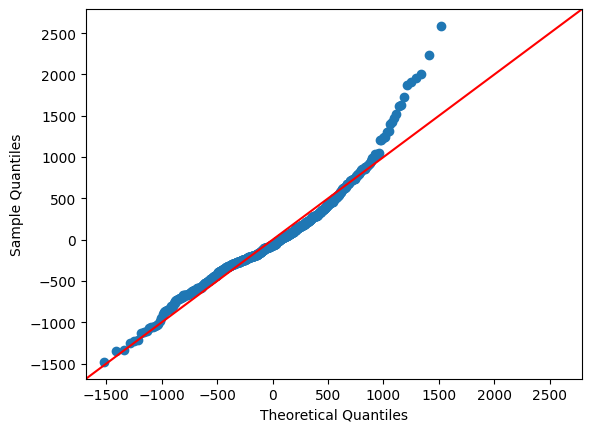

In [37]:
plot_residuals_distribution(model, nbins=100)


The ARIMA model assumes that the residuals are i.i.d with zero mean and constant variance. Additionally, they are often assumed to be normally distributed. Observation of the residuals histogram suggests that their empirical distribution follow indeed a normal distribution centered around 0 because its KDE fitted distribution (in red) does not deviate much from a normal distribution with estimated expectancy and standard deviation.
A Q-Q plot provides an alternative way to assess deviations from normality (see figure above). The residuals are generally consistent with a normalal distribution except at the highest quantiles, where deviation from the normality begins to appear.

This assessment is based solely on visual observation, formalm statistical tests are required to provide evidence against the normal centered distribution assumption.

## Southern Oscillation Index

### Question 11

In [38]:
df_soi = pd.read_csv("soi.tsv",sep='\t', header=None)
df_soi = df_soi.T

In [39]:
df_soi.head()


,0
0,1.537160
1,0.922168
2,-0.104204
3,-0.291903
4,-0.658745


In [40]:
df_soi.tail()

,0
776,-1.630080
777,-1.699540
778,-0.502287
779,-0.555563
780,NaN


In [41]:
df_soi.isna().sum()
df_soi = df_soi.dropna() #only last one NA

In [42]:
df_soi[0]

0      1.537160
1      0.922168
2     -0.104204
3     -0.291903
4     -0.658745
         ...   
775   -1.423410
776   -1.630080
777   -1.699540
778   -0.502287
779   -0.555563
Name: 0, Length: 780, dtype: float64

In [43]:
fig = px.line(df_soi, y=0, title="South Oscillation Index")
fig.update_xaxes(title_text='Index')
fig.update_yaxes(title_text='Value')

### Question 12

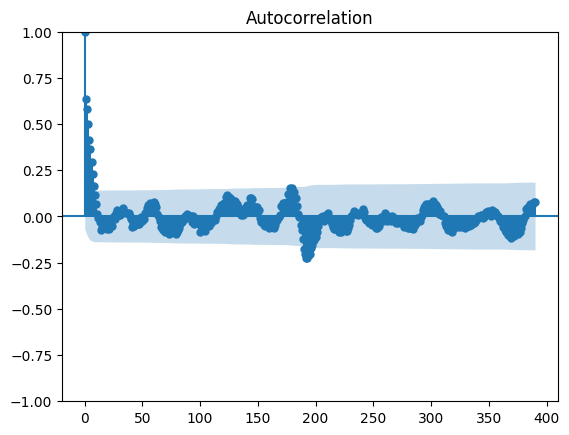

In [44]:
fig, ax = plt.subplots()
plot_acf(df_soi[0].values.squeeze(), lags=390, ax=ax)
plt.show()

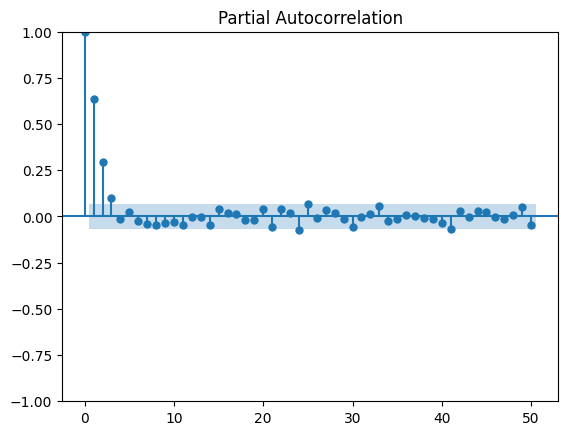

In [45]:
fig, ax = plt.subplots()
plot_pacf(df_soi[0].values.squeeze(), lags=50, ax=ax)
plt.show()

### Question 13

Based on the previous plots, the selected order for the AR model is $p=4$. Indeed the partial autocorrelation (PACF) measures the direct influence of past observations on the current one after removing the effect of intermediate lags. From the PACF plot, the only significant lags are 0, 1, 2, 3 (those outside of the blue confidence zone). Hence, we choose p as the maximal significant value.

The fact that the autocorrelation function (ACF) decays slowly and has a significant value for the lag 4 confirms our choice for $p=4$ for an AR model.

In [46]:
soi_values = df_soi.iloc[:,0].to_numpy()
soi_time = np.arange(len(soi_values))

In [47]:
p = 3
train_test_ratio = 20
model, t_train, t_test, y_train, y_test, y_pred = forecast_arima(train_test_ratio, soi_time, soi_values, p, title='Prediction of South Oscillation Index')

(743,)
(37,)


P = 4 | AIC 1580.344893392817 | BIC 1603.398373616406 | MSE 0.7189581789588232


ARIMA parameters
const: 0.14975122437059238
ar.L1: 0.4235424484016507
ar.L2: 0.24703515779942667
ar.L3: 0.09984522728412995
sigma2: 0.48415135466977094
Emprical mean =  -0.0022803703257448927
Empirical std =  0.6966861086035939


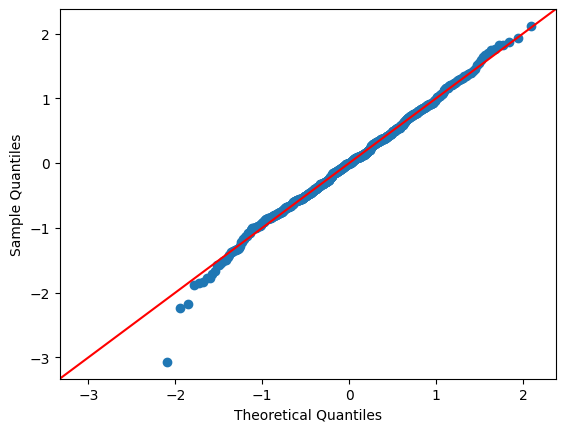

In [48]:
plot_residuals_distribution(model, nbins=100)

The analysis is analogous to that in Question 10.
However, in this case the deviations from the normality appear smaller than those observed in Part 2, as indicated by the close agreement between the estimated density and the fitted normal distribution, as well as by the Q-Q plot.

### Question 14

In [49]:
freq_orig, power_orig = signal.periodogram(x = y_train, fs=1)

phis_dict = {k:v for k, v in zip(model.param_names, model.params)}
sig2 = phis_dict["sigma2"]

omega = np.linspace(0, 0.5, 1000)

# Build the exponent
k = np.arange(p+1)
exponent = -2j*np.pi*np.outer(k,omega)
phis = model.params[:-1]

# Build the spectrum
summation = phis@np.exp(exponent)
spectral_density = sig2/np.square(np.abs(1-summation))

labels = ["Periodogram", "Estimated Spectral Density"]
x = [freq_orig[1:], omega]
y = [power_orig[1:], spectral_density]

fig = go_multiple_one_fig(labels, x, y,xaxes="freq",yaxes="power",title="Periodogram vs Spectral Density of AR Model")
fig.update_yaxes(type="log")
fig.update_layout(title="Periodogram vs Spectral Density of AR Model in a Rescaled Logarithmic Scale")

We observe that the periodogram computed on the training dataset is closely related with the spectral density given by the AR(p) model with p=3 here. This confirms visually that the AR(p) model is a realistic assumption for the SOI time series especially when combining this result with the previous one.


